<center>

# **Primera pueba de MLP**

</center>


---

**Autor**: Isaac Yael Cantú Fernández

**Fecha**: 10/04/2026

## **2. Red Neuronal (MLP)**

---

En esta sección se implementará una red neuronal básica con el fin de realizar las primeras pruebas del comportamiento de los datos

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### **2.1 Cargar datos**

196 x 7 = 2752 entradas

4 x 4 -> 12 x 12
n x n x 

grid x y
cantidad de partículas en cada grid 
energia total *suma de todas las energías
media de las enegías
desviaión de las energías
promedio al tiempo 

tensor de 8 x 8 x 5 = 320 parametros (entrada) 
+ 13 neuronas de  

333 entrada


> **GRID de datos**

> **Base de datos para entrenar**

In [35]:
df_particles = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/corsario_5000.csv")
df_shower    = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/shower_corsario_5000.csv")

GRID = 8

features = ["x","y","energy","t"]

# rangos espaciales
x_bins = np.linspace(df_particles["x"].min(), df_particles["x"].max(), GRID+1)
y_bins = np.linspace(df_particles["y"].min(), df_particles["y"].max(), GRID+1)


def build_tensor(shower_particles):

    tensor = np.zeros((GRID, GRID, 6))

    for i in range(GRID):
        for j in range(GRID):

            mask = (
                (shower_particles["x"] >= x_bins[i]) &
                (shower_particles["x"] < x_bins[i+1]) &
                (shower_particles["y"] >= y_bins[j]) &
                (shower_particles["y"] < y_bins[j+1])
            )

            cell = shower_particles[mask]

            if len(cell) > 0:

                energies = cell["energy"].values
                times = cell["t"].values

                tensor[i,j,0] = len(cell)                # conteo
                tensor[i,j,1] = energies.sum()           # energía total
                tensor[i,j,2] = energies.mean()          # energía media
                tensor[i,j,3] = energies.std()           # std energía
                tensor[i,j,4] = times.mean()             # tiempo medio
                tensor[i,j,5] = times.std()             # tiempo medio

    return tensor

X = []
y = []

for shower_id, group in df_particles.groupby("shower"):

    tensor = build_tensor(group)

    X.append(tensor)

    energy = df_shower.loc[
        df_shower["event_no"] == int(shower_id),
        "total_energy"
    ].values[0]

    y.append(energy)

X = np.array(X)
y = np.array(y)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

import torch

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

X = (X - X.mean()) / (X.std() + 1e-8)
y = np.log1p(y)

from torch.utils.data import Dataset, DataLoader

class ShowerDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        grid = self.X[idx].reshape(-1)#.permute(2,0,1)  # (channels,8,8)
        target = self.y[idx]

        return grid, target

from torch.utils.data import DataLoader, random_split

dataset = ShowerDataset(X,y)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset,[train_size,val_size])

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32)


Shape X: (4977, 8, 8, 6)
Shape y: (4977,)


/tmp/ipykernel_5998/1574690699.py:71: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = np.log1p(y)


# 88

In [117]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# ─────────────────────────────────────────────────────────────
# 0. CARGA DE DATOS
# ─────────────────────────────────────────────────────────────

df_particles = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/corsario_5000.csv")
df_shower    = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/shower_corsario_5000.csv")


# ─────────────────────────────────────────────────────────────
# 1. GRID GENERATOR — Lógica Original
# ─────────────────────────────────────────────────────────────

def grid_generator(n: int = 8, df_particles=None, df_shower=None):
    
    # Rangos espaciales globales
    x_bins = np.linspace(df_particles["x"].min(), df_particles["x"].max(), n+1)
    y_bins = np.linspace(df_particles["y"].min(), df_particles["y"].max(), n+1)
    
    def build_tensor(shower_particles):
        # Asumimos que 'n', 'x_bins' y 'y_bins' están definidos globalmente (o cámbialos por 'GRID')
        tensor = np.zeros((n, n, 6))

        # 1. Asignar a qué índice (bin) pertenece cada partícula en UNA sola pasada
        # np.digitize devuelve el índice + 1, por lo que restamos 1.
        ix = np.digitize(shower_particles["x"], x_bins) - 1
        iy = np.digitize(shower_particles["y"], y_bins) - 1

        # 2. Filtrar partículas que caigan fuera de los límites del Grid
        valid = (ix >= 0) & (ix < n) & (iy >= 0) & (iy < n)
        
        # Si ninguna partícula cae dentro del grid, devolvemos el tensor en ceros
        if not valid.any():
            return tensor

        # 3. Crear un DataFrame solo con las partículas válidas y sus índices de celda
        df_valid = shower_particles[valid].copy()
        df_valid["ix"] = ix[valid]
        df_valid["iy"] = iy[valid]

        # 4. Agrupar por celda (ix, iy) y calcular todas las estadísticas de golpe
        # Usamos ddof=0 en el std para igualar exactamente el cálculo que hacía .values.std() de NumPy
        stats = df_valid.groupby(["ix", "iy"]).agg(
            count=("energy", "size"),
            e_sum=("energy", "sum"),
            e_mean=("energy", "mean"),
            e_std=("energy", lambda x: np.std(x, ddof=0)),
            t_mean=("t", "mean"),
            t_std=("t", lambda x: np.std(x, ddof=0))
        ).reset_index()

        # 5. Inyectar los resultados en el Tensor usando "Advanced Indexing" de NumPy (Cero loops)
        i_idx = stats["ix"].astype(int).values
        j_idx = stats["iy"].astype(int).values

        tensor[i_idx, j_idx, 0] = stats["count"]
        tensor[i_idx, j_idx, 1] = stats["e_sum"]
        tensor[i_idx, j_idx, 2] = stats["e_mean"]
        tensor[i_idx, j_idx, 3] = stats["e_std"].fillna(0.0) # Evita NaNs si solo hay 1 partícula
        tensor[i_idx, j_idx, 4] = stats["t_mean"]
        tensor[i_idx, j_idx, 5] = stats["t_std"].fillna(0.0)

        return tensor

    X = []
    y = []

    # Construcción de tensores por shower
    for shower_id, group in df_particles.groupby("shower"):
        
        tensor = build_tensor(group)
        X.append(tensor)

        energy = df_shower.loc[
            df_shower["event_no"] == int(shower_id),
            "total_energy"
        ].values[0]
        y.append(energy)

    X = np.array(X)
    y = np.array(y)

    # Aplanar el tensor espacial para la MLP: (N_showers, n*n*6)
    X = X.reshape(len(X), -1)
    
    # Aplicar logaritmo a la energía (como en tu código original)
    y = np.log1p(y)

    return X, y


# ─────────────────────────────────────────────────────────────
# 2. SPLIT + NORMALIZACIÓN GLOBAL
# ─────────────────────────────────────────────────────────────

def split_data(X, y, train=70, test=15, val=15, seed=42):
    
    # 1. Splits
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=train / 100, shuffle=True, random_state=seed
    )
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, train_size=test / (test + val), shuffle=True, random_state=seed
    )

    # 2. Normalización ROBUSTA (Global)
    # Calculamos la media y std de todo el bloque de entrenamiento a la vez
    X_mean = X_train.mean() 
    X_std  = X_train.std() + 1e-8

    X_train_n = (X_train - X_mean) / X_std
    X_val_n   = (X_val   - X_mean) / X_std
    X_test_n  = (X_test  - X_mean) / X_std

    # 3. Conversión a Tensores
    def tt(arr): return torch.tensor(arr, dtype=torch.float32)

    train_ds = TensorDataset(tt(X_train_n), tt(y_train).view(-1, 1))
    val_ds   = TensorDataset(tt(X_val_n),   tt(y_val).view(-1, 1))
    test_ds  = TensorDataset(tt(X_test_n),  tt(y_test).view(-1, 1))

    return train_ds, val_ds, test_ds


# ─────────────────────────────────────────────────────────────
# 3. EJECUCIÓN
# ─────────────────────────────────────────────────────────────

# Generar arrays Numpy
X_np, y_np = grid_generator(n=8, df_particles=df_particles, df_shower=df_shower)

print("Shape X (Numpy):", X_np.shape)
print("Shape y (Numpy):", y_np.shape)

# Dividir y normalizar para PyTorch
train_dataset, val_dataset, test_dataset = split_data(X_np, y_np)

# DataLoaders
BATCH = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH, shuffle=False)

Shape X (Numpy): (4977, 384)
Shape y (Numpy): (4977,)


In [96]:
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import PCA
from scipy.stats import skew

def stats_generator(df_particles=None, df_shower=None):

    # 1. ORDENAMOS los showers para tener una referencia fija y segura
    showers = np.sort(df_particles["shower"].unique())
    n_showers = len(showers)

    # 16 features
    stats_data = np.zeros((n_showers, 17))

    for i, shower in enumerate(showers):

        data = df_particles[df_particles["shower"] == shower]

        x = data["x"].values
        y = data["y"].values
        t = data["t"].values
        e = data["energy"].values
        e = np.log1p(e)

        # -------------------------
        # 1. medias espaciales
        # -------------------------
        cant_p = len(x)
        x_mean = x.mean()
        y_mean = y.mean()
        
        # -------------------------
        # 2. PCA espacial (x,y)
        # -------------------------
        if len(data) >= 2:
            coords = np.vstack((x, y)).T
            coords_scaled = StandardScaler().fit_transform(coords)

            pca = PCA(n_components=2)
            pca.fit(coords_scaled)

            eigenvalues = pca.explained_variance_
            eigenvectors = pca.components_

            lambda1, lambda2 = eigenvalues

            # ángulo del eje principal
            v1 = eigenvectors[0]
            angle = np.arctan2(v1[1], v1[0])  # radianes
        else:
            # Fallback para showers con solo 1 partícula
            lambda1, lambda2, angle = 0.0, 0.0, 0.0

        # (Se eliminaron las líneas repetidas de v1 y angle que estaban aquí y causaban un bug)

        # -------------------------
        # 3. tiempo
        # -------------------------
        t_mean = t.mean()
        t_std = t.std()
        t_skew = skew(t) if len(t) > 2 else 0

        # -------------------------
        # 4. energía
        # -------------------------
        e_sum = e.sum()
        e_mean = e.mean()
        e_var = e.var()
        e_max = e.max()

        # -------------------------
        # 5. covarianzas
        # -------------------------
        cov_xt = np.cov(x, t)[0,1] if len(x) > 1 else 0
        cov_yt = np.cov(y, t)[0,1] if len(y) > 1 else 0

        # -------------------------
        # 6. radio
        # -------------------------
        r = np.sqrt((x - x_mean)**2 + (y - y_mean)**2)

        r_mean = r.mean()
        r_var = r.var()

        # -------------------------
        # vector final
        # -------------------------
        stats_data[i] = [
            cant_p,
            x_mean,
            y_mean,
            lambda1,
            lambda2,
            angle,
            t_mean,
            t_std,
            t_skew,
            e_sum,
            e_mean,
            e_var,
            e_max,
            cov_xt,
            cov_yt,
            r_mean,
            r_var
        ]

    # -------------------------
    # Target ALINEADO
    # -------------------------
    # 2. Usamos .set_index y .loc pasando nuestra lista ordenada de 'showers'
    # Esto fuerza a que df_shower nos devuelva las filas EXACTAMENTE en el 
    # mismo orden del loop, y automáticamente filtra cualquier event_no que falte.
    df_shower_aligned = df_shower.set_index("event_no").loc[showers]
    
    output_data = np.log1p(df_shower_aligned["total_energy"].values)

    return stats_data, output_data

def split_data(X, y, train=70, test=15, val=15, seed=42):
    
    # 1. Splits
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=train / 100, shuffle=True, random_state=seed
    )
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, train_size=test / (test + val), shuffle=True, random_state=seed
    )

    # 2. Normalización ROBUSTA (Global)
    # Calculamos la media y std de todo el bloque de entrenamiento a la vez
    X_mean = X_train.mean() 
    X_std  = X_train.std() + 1e-8

    X_train_n = (X_train - X_mean) / X_std
    X_val_n   = (X_val   - X_mean) / X_std
    X_test_n  = (X_test  - X_mean) / X_std

    # 3. Conversión a Tensores
    def tt(arr): return torch.tensor(arr, dtype=torch.float32)

    train_ds = TensorDataset(tt(X_train_n), tt(y_train).view(-1, 1))
    val_ds   = TensorDataset(tt(X_val_n),   tt(y_val).view(-1, 1))
    test_ds  = TensorDataset(tt(X_test_n),  tt(y_test).view(-1, 1))

    return train_ds, val_ds, test_ds

# Generar arrays Numpy
X_np, y_np = stats_generator(df_particles=df_particles, df_shower=df_shower)

print("Shape X (Numpy):", X_np.shape)
print("Shape y (Numpy):", y_np.shape)

# Dividir y normalizar para PyTorch
train_dataset, val_dataset, test_dataset = split_data(X_np, y_np)

# DataLoaders
BATCH = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH, shuffle=False)

Shape X (Numpy): (4977, 17)
Shape y (Numpy): (4977,)


# l

X shape         : (4977, 384)
y shape         : (4977,)
Energy range    : 100.01 – 14842.64
Showers vacíos  : 0

Batch X : torch.Size([32, 384])
Batch y : torch.Size([32, 1])
y sample: tensor([[4.7765],
        [4.9335],
        [4.6464],
        [4.9035],
        [5.1597]])


/home/icantu24/Documents/ARCHES/.venv/lib64/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/icantu24/Documents/ARCHES/.venv/lib64/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([27, 1])) that is different to the input size (torch.Size([27])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/icantu24/Documents/ARCHES/.venv/lib64/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([11, 1])) that is different to the input size (torch.Size([11])). This will likely lead to incorrect results

Epoch   1 | Train: 6.4001 | Val: 0.4189
Epoch  10 | Train: 0.4375 | Val: 0.3062
Epoch  20 | Train: 0.4197 | Val: 0.2974
Epoch  30 | Train: 0.4096 | Val: 0.3061
Epoch  40 | Train: 0.4053 | Val: 0.2930
Epoch  50 | Train: 0.4031 | Val: 0.2916
Epoch  60 | Train: 0.4022 | Val: 0.2925
Epoch  70 | Train: 0.4035 | Val: 0.2931
Epoch  80 | Train: 0.4015 | Val: 0.2920
Epoch  90 | Train: 0.4024 | Val: 0.2919
Epoch 100 | Train: 0.4064 | Val: 0.2935

Mejor val loss: 0.2914

Test  MAE : 0.44
Test  RMSE: 0.59
Test  R²  : -753.1613


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (24,) + inhomogeneous part.

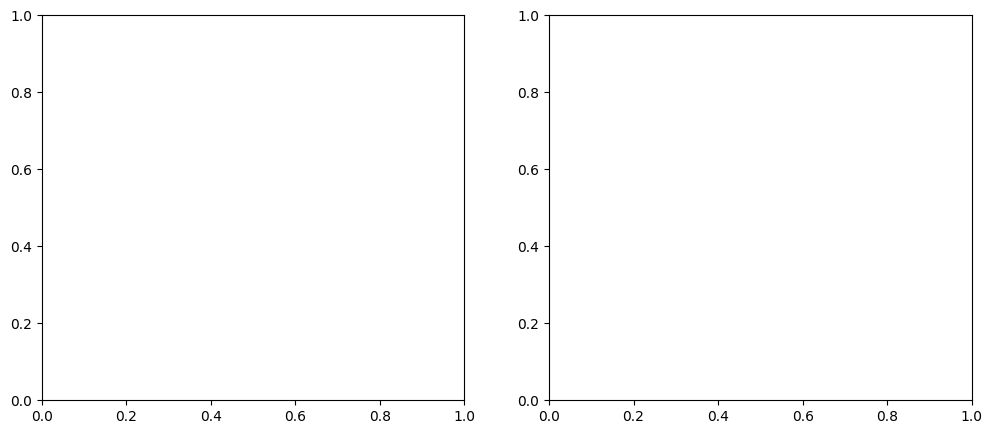

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt


# ─────────────────────────────────────────────────────────────
# 0. CARGA DE DATOS
# ─────────────────────────────────────────────────────────────

df_particles = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/corsario_5000.csv")
df_shower    = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/shower_corsario_5000.csv")


# ─────────────────────────────────────────────────────────────
# 1. GRID GENERATOR — 6 canales, shape (N, 6, n, n)
#
#    Canales por celda:
#      0 — conteo de partículas
#      1 — suma de energía
#      2 — media de energía
#      3 — desviación estándar de energía
#      4 — media de tiempo
#      5 — desviación estándar de tiempo
# ─────────────────────────────────────────────────────────────

def grid_generator_fast(n: int = 8, df_particles=None, df_shower=None):

    # Orden fijo y reproducible → garantiza grid[i] == total_energy[i]
    showers   = np.sort(df_particles["shower"].unique())
    n_showers = len(showers)

    df = df_particles.copy()

    # Centrar coordenadas por shower ANTES de calcular los bins
    # (cada shower queda centrado en su propio centro de masa)
    df["x"] = df.groupby("shower")["x"].transform(lambda s: s - s.mean())
    df["y"] = df.groupby("shower")["y"].transform(lambda s: s - s.mean())

    # Bins globales sobre las coordenadas ya centradas
    max_range = max(df["x"].abs().max(), df["y"].abs().max())
    x_bins = np.linspace(-max_range, max_range, n + 1)
    y_bins = np.linspace(-max_range, max_range, n + 1)

    # Índices de celda (np.digitize devuelve 1-based → restar 1)
    df["ix"] = np.digitize(df["x"], x_bins) - 1
    df["iy"] = np.digitize(df["y"], y_bins) - 1

    # Recortar borde superior (np.digitize mete el máximo en bin n)
    df = df[
        (df["ix"] >= 0) & (df["ix"] < n) &
        (df["iy"] >= 0) & (df["iy"] < n)
    ]

    # Estadísticas por (shower, celda_x, celda_y) en una sola pasada
    stats = (
        df.groupby(["shower", "ix", "iy"])
        .agg(
            count       = ("energy", "size"),
            energy_sum  = ("energy", "sum"),
            energy_mean = ("energy", "mean"),
            energy_std  = ("energy", "std"),
            time_mean   = ("t",      "mean"),
            time_std    = ("t",      "std"),
        )
        .reset_index()
    )

    # Tensor de salida: (N_showers, 6_canales, n, n)
    grid = np.zeros((n_showers, 6, n, n), dtype=np.float32)
    shower_to_idx = {sh: idx for idx, sh in enumerate(showers)}

    for _, row in stats.iterrows():
        i = shower_to_idx[row["shower"]]
        j = int(row["ix"])
        k = int(row["iy"])
        grid[i, :, j, k] = [
            row["count"],
            row["energy_sum"],
            row["energy_mean"],
            0.0 if np.isnan(row["energy_std"]) else row["energy_std"],
            row["time_mean"],
            0.0 if np.isnan(row["time_std"])   else row["time_std"],
        ]

    # Target alineado con el mismo orden de showers
    shower_lookup = df_shower.set_index("event_no")["total_energy"]

    y = []

    for shower_id, group in df_particles.groupby("shower"):

        energy = df_shower.loc[
            df_shower["event_no"] == int(shower_id),
            "total_energy"
        ].values[0]

        y.append(energy)

    y = np.array(y)

    # Aplanar: (N, 6*n*n)
    X = grid.reshape(n_showers, 6 * n * n)

    return X, y


# ─────────────────────────────────────────────────────────────
# 2. SPLIT + NORMALIZACIÓN
# ─────────────────────────────────────────────────────────────

def split_data(X, y, train=70, test=15, val=15, seed=42):
    # 1. Splits normales
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=train / 100, shuffle=True, random_state=seed
    )
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, train_size=test / (test + val), shuffle=True, random_state=seed
    )

    # 2. NORMALIZACIÓN ROBUSTA (Global)
    # Usamos la media y std de TODO el bloque de entrenamiento, no por columna.
    # Esto evita que columnas vacías disparen los valores a infinito.
    X_mean = X_train.mean() 
    X_std  = X_train.std() + 1e-8

    X_train_n = (X_train - X_mean) / X_std
    X_val_n   = (X_val   - X_mean) / X_std
    X_test_n  = (X_test  - X_mean) / X_std

    # 3. Conversión a Tensores
    def tt(arr): return torch.tensor(arr, dtype=torch.float32)

    # Aseguramos que 'y' tenga la forma (Batch, 1) para evitar errores de broadcasting
    train_ds = TensorDataset(tt(X_train_n), tt(y_train).view(-1, 1))
    val_ds   = TensorDataset(tt(X_val_n),   tt(y_val).view(-1, 1))
    test_ds  = TensorDataset(tt(X_test_n),  tt(y_test).view(-1, 1))

    return train_ds, val_ds, test_ds


# ─────────────────────────────────────────────────────────────
# 3. PIPELINE
# ─────────────────────────────────────────────────────────────

X_raw, E_raw = grid_generator_fast(n=8, df_particles=df_particles, df_shower=df_shower)

# Sanity checks
print(f"X shape         : {X_raw.shape}")          # (N, 384)  ← 6*8*8
print(f"y shape         : {E_raw.shape}")           # (N,)
print(f"Energy range    : {E_raw.min():.2f} – {E_raw.max():.2f}")
print(f"Showers vacíos  : {(X_raw == 0).all(axis=1).sum()}")

assert (E_raw >= 0).all(), "Hay energías negativas — revisa df_shower"

# Log-transform del target
y_log = np.log1p(E_raw)

train_ds, val_ds, test_ds = split_data(X_raw, y_log)

BATCH = 32
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

# Verificación rápida
Xb, yb = next(iter(train_loader))
print(f"\nBatch X : {Xb.shape}")   # (32, 384)
print(f"Batch y : {yb.shape}")     # (32,)
print(f"y sample: {yb[:5]}")       # valores distintos entre sí ← señal sana


# ─────────────────────────────────────────────────────────────
# 4. MODELO MLP
# ─────────────────────────────────────────────────────────────

INPUT_DIM = X_raw.shape[1]   # 6 * 8 * 8 = 384

class ShowerMLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


# ─────────────────────────────────────────────────────────────
# 5. ENTRENAMIENTO
# ─────────────────────────────────────────────────────────────

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = ShowerMLP(INPUT_DIM).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS      = 100
best_val    = float("inf")
history     = {"train": [], "val": []}

for epoch in range(1, EPOCHS + 1):

    # — Train —
    model.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(Xb)
    train_loss /= len(train_ds)

    # — Val —
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            val_loss += criterion(model(Xb), yb).item() * len(Xb)
    val_loss /= len(val_ds)

    scheduler.step(val_loss)
    history["train"].append(train_loss)
    history["val"].append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "best_model.pt")

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

print(f"\nMejor val loss: {best_val:.4f}")


# ─────────────────────────────────────────────────────────────
# 6. EVALUACIÓN EN TEST  (escala original)
# ─────────────────────────────────────────────────────────────

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

y_true_list, y_pred_list = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        pred = model(Xb).cpu().numpy()
        y_pred_list.append(pred)
        y_true_list.append(yb.numpy())

y_true_norm = np.concatenate(y_true_list)
y_pred_norm = np.concatenate(y_pred_list)

# Desnormalizar y deshacer log1p
#y_mean, y_std = meta["y_mean"], meta["y_std"]
y_true = y_true_norm#np.expm1(y_true_norm * y_std + y_mean)
y_pred = y_pred_norm#np.expm1(y_pred_norm * y_std + y_mean)

# Métricas
mae  = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
print(f"\nTest  MAE : {mae:.2f}")
print(f"Test  RMSE: {rmse:.2f}")
print(f"Test  R²  : {r2:.4f}")

# Gráfica y_true vs y_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_true, y_pred, alpha=0.4, s=15)
lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[0].plot(lim, lim, "r--", lw=1.5, label="ideal")
axes[0].set_xlabel("E verdadera")
axes[0].set_ylabel("E predicha")
axes[0].set_title(f"y_true vs y_pred  (R²={r2:.3f})")
axes[0].legend()

axes[1].plot(history["train"], label="train")
axes[1].plot(history["val"],   label="val")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE (espacio normalizado)")
axes[1].set_title("Curvas de pérdida")
axes[1].legend()

plt.tight_layout()
plt.savefig("resultados.png", dpi=150)
plt.show()

### **2.2 Arquitectura de MLP**

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# ─────────────────────────────────────────────────────────────
# 0. CARGA DE DATOS
# ─────────────────────────────────────────────────────────────

df_particles = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/corsario_5000.csv")
df_shower    = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/shower_corsario_5000.csv")


In [85]:
import torch

def grid_generator_torch(df_particles, df_shower, n=8, device="cpu"):

    # convertir a torch 
    x = torch.tensor(df_particles["x"].values, dtype=torch.float32, device=device)
    y = torch.tensor(df_particles["y"].values, dtype=torch.float32, device=device)
    e = torch.tensor(np.log1p(df_particles["energy"]).values, dtype=torch.float32, device=device)
    t = torch.tensor(df_particles["t"].values, dtype=torch.float32, device=device)
    shower_id = torch.tensor(df_particles["shower"].values, dtype=torch.long, device=device)

    # mapear showers a índices 
    showers = df_particles.shower.unique()
    unique_showers, shower_idx = torch.unique(shower_id, return_inverse=True)
    n_showers = unique_showers.shape[0]

    # bins 
    x_bins = torch.linspace(x.min(), x.max(), n+1, device=device)
    y_bins = torch.linspace(y.min(), y.max(), n+1, device=device)

    ix = torch.bucketize(x, x_bins) - 1
    iy = torch.bucketize(y, y_bins) - 1

    # máscara válida 
    valid = (ix >= 0) & (ix < n) & (iy >= 0) & (iy < n)

    ix = ix[valid]
    iy = iy[valid]
    e = e[valid]
    t = t[valid]
    shower_idx = shower_idx[valid]

    # índice global 
    flat_idx = shower_idx * (n*n) + ix * n + iy

    # acumulaciones 
    size = n_showers * n * n

    count = torch.zeros(size, device=device)
    e_sum = torch.zeros(size, device=device)
    e_sq_sum = torch.zeros(size, device=device)
    t_sum = torch.zeros(size, device=device)
    t_sq_sum = torch.zeros(size, device=device)

    ones = torch.ones_like(e)

    count.scatter_add_(0, flat_idx, ones)
    e_sum.scatter_add_(0, flat_idx, e)
    e_sq_sum.scatter_add_(0, flat_idx, e**2)
    t_sum.scatter_add_(0, flat_idx, t)
    t_sq_sum.scatter_add_(0, flat_idx, t**2)

    # reshape
    count = count.view(n_showers, n, n)
    e_sum = e_sum.view(n_showers, n, n)

    # medias
    eps = 1e-8
    mask = count > 0

    e_mean = torch.zeros_like(e_sum)
    t_mean = torch.zeros_like(t_sum.view(n_showers, n, n))

    e_mean[mask] = e_sum[mask] / count[mask]
    t_mean[mask] = t_sum.view(n_showers, n, n)[mask] / count[mask]

    # varianzas
    e_var = e_sq_sum.view(n_showers, n, n)/(count+eps) - e_mean**2
    t_var = t_sq_sum.view(n_showers, n, n)/(count+eps) - t_mean**2

    # std seguras
    e_std = torch.sqrt(torch.clamp(e_var, min=0.0))
    t_std = torch.sqrt(torch.clamp(t_var, min=0.0))

    # stack final
    X = torch.stack([count, e_sum, e_mean, e_std, t_mean, t_std], dim=-1)

    # flatten
    X = X.view(n_showers, -1)

    # target
    mapping = {val.item(): i for i, val in enumerate(unique_showers)}
    df_shower["idx"] = df_shower["event_no"].map(mapping)
    df_shower = df_shower.dropna().sort_values("idx")

    y = torch.tensor(df_shower["total_energy"].values, dtype=torch.float32, device=device)

    y = torch.log1p(y)

    return X, y

X,y = grid_generator_torch(df_particles, df_shower, n=6, device="cpu")
print(X.shape, y.shape)
print((torch.isnan(y)).any())

torch.Size([4977, 216]) torch.Size([4977])
tensor(False)


In [99]:
import torch
import numpy as np

def circle_generator_torch(df_particles, df_shower, device="cpu"):

    # -------- tensors --------
    x = torch.tensor(df_particles["x"].values, dtype=torch.float32, device=device)
    y = torch.tensor(df_particles["y"].values, dtype=torch.float32, device=device)
    e = torch.tensor(np.log1p(df_particles["energy"].values), dtype=torch.float32, device=device)
    t = torch.tensor(df_particles["t"].values, dtype=torch.float32, device=device)
    shower_id = torch.tensor(df_particles["shower"].values, dtype=torch.long, device=device)

    # -------- mapping --------
    unique_showers, shower_idx = torch.unique(shower_id, return_inverse=True)
    n_showers = unique_showers.shape[0]

    # -------- medias por shower --------
    count = torch.zeros(n_showers, device=device)
    x_sum = torch.zeros(n_showers, device=device)
    y_sum = torch.zeros(n_showers, device=device)

    ones = torch.ones_like(x)

    count.scatter_add_(0, shower_idx, ones)
    x_sum.scatter_add_(0, shower_idx, x)
    y_sum.scatter_add_(0, shower_idx, y)

    x_mean = x_sum / (count + 1e-8)
    y_mean = y_sum / (count + 1e-8)

    # -------- centrar --------
    x_c = x - x_mean[shower_idx]
    y_c = y - y_mean[shower_idx]

    r = torch.sqrt(x_c**2 + y_c**2)

    # -------- sigma radial --------
    r_sum = torch.zeros(n_showers, device=device)
    r_sq_sum = torch.zeros(n_showers, device=device)

    r_sum.scatter_add_(0, shower_idx, r)
    r_sq_sum.scatter_add_(0, shower_idx, r**2)

    r_mean = r_sum / (count + 1e-8)
    r_var = r_sq_sum/(count+1e-8) - r_mean**2
    sigma = torch.sqrt(torch.clamp(r_var, min=0.0))

    # -------- bins --------
    r_bins = torch.stack([sigma * i for i in range(1,5)], dim=1)  # (n_showers, 4)

    # -------- asignar anillos --------
    # expandir para comparar
    r_exp = r.unsqueeze(1)  # (N_particles, 1)
    bins = r_bins[shower_idx]  # (N_particles, 4)

    ring_idx = torch.zeros_like(r, dtype=torch.long)

    ring_idx += (r > bins[:,0])
    ring_idx += (r > bins[:,1])
    ring_idx += (r > bins[:,2])
    ring_idx += (r > bins[:,3])

    ring_idx = torch.clamp(ring_idx, max=3)

    # -------- índice combinado (shower + ring) --------
    flat_idx = shower_idx * 4 + ring_idx
    size = n_showers * 4

    # -------- acumulaciones --------
    count_r = torch.zeros(size, device=device)
    e_sum = torch.zeros(size, device=device)
    e_sq_sum = torch.zeros(size, device=device)
    t_sum = torch.zeros(size, device=device)
    t_sq_sum = torch.zeros(size, device=device)

    count_r.scatter_add_(0, flat_idx, ones)
    e_sum.scatter_add_(0, flat_idx, e)
    e_sq_sum.scatter_add_(0, flat_idx, e**2)
    t_sum.scatter_add_(0, flat_idx, t)
    t_sq_sum.scatter_add_(0, flat_idx, t**2)

    # -------- reshape --------
    count_r = count_r.view(n_showers, 4)
    e_sum = e_sum.view(n_showers, 4)
    t_sum = t_sum.view(n_showers, 4)

    # -------- medias --------
    mask = count_r > 0

    e_mean = torch.zeros_like(e_sum)
    t_mean = torch.zeros_like(t_sum)

    e_mean[mask] = e_sum[mask] / count_r[mask]
    t_mean[mask] = t_sum[mask] / count_r[mask]

    # -------- std --------
    e_var = e_sq_sum.view(n_showers,4)/(count_r+1e-8) - e_mean**2
    t_var = t_sq_sum.view(n_showers,4)/(count_r+1e-8) - t_mean**2

    e_std = torch.sqrt(torch.clamp(e_var, min=0.0))
    t_std = torch.sqrt(torch.clamp(t_var, min=0.0))

    # -------- features --------
    features = torch.stack([
        count_r,
        e_sum,
        e_mean,
        e_std,
        t_mean,
        t_std
    ], dim=2)  # (n_showers, 4, 6)

    features = features.view(n_showers, -1)  # (n_showers, 24)

    # -------- covarianza --------
    xx = torch.zeros(n_showers, device=device)
    yy = torch.zeros(n_showers, device=device)
    xy = torch.zeros(n_showers, device=device)

    xx.scatter_add_(0, shower_idx, x_c**2)
    yy.scatter_add_(0, shower_idx, y_c**2)
    xy.scatter_add_(0, shower_idx, x_c*y_c)

    cov_xx = xx / (count + 1e-8)
    cov_yy = yy / (count + 1e-8)
    cov_xy = xy / (count + 1e-8)

    cov = torch.stack([cov_xx, cov_xy, cov_xy, cov_yy], dim=1)

    # -------- final --------
    X = torch.cat([
        x_mean.unsqueeze(1),
        y_mean.unsqueeze(1),
        cov,
        features
    ], dim=1)

    # -------- target --------
    mapping = {val.item(): i for i, val in enumerate(unique_showers)}
    df_shower["idx"] = df_shower["event_no"].map(mapping)
    df_shower = df_shower.dropna().sort_values("idx")

    y = torch.tensor(df_shower["total_energy"].values, dtype=torch.float32, device=device)
    y = torch.log1p(y)

    return X, y

X,y = circle_generator_torch(df_particles, df_shower, device="cpu")
print(X.shape, y.shape)
print((torch.isnan(y)).any())

torch.Size([4977, 30]) torch.Size([4977])
tensor(False)


In [111]:
import torch
import numpy as np

def stats_generator_torch(df_particles, df_shower, device="cpu"):

    # -------- tensors --------
    x = torch.tensor(df_particles["x"].values, dtype=torch.float32, device=device)
    y = torch.tensor(df_particles["y"].values, dtype=torch.float32, device=device)
    t = torch.tensor(df_particles["t"].values, dtype=torch.float32, device=device)
    e = torch.tensor(np.log1p(df_particles["energy"].values), dtype=torch.float32, device=device)
    shower_id = torch.tensor(df_particles["shower"].values, dtype=torch.long, device=device)

    # -------- mapping --------
    unique_showers, shower_idx = torch.unique(shower_id, return_inverse=True)
    n_showers = unique_showers.shape[0]

    ones = torch.ones_like(x)

    # -------- conteo --------
    count = torch.zeros(n_showers, device=device)
    count.scatter_add_(0, shower_idx, ones)

    # -------- medias --------
    x_sum = torch.zeros(n_showers, device=device)
    y_sum = torch.zeros(n_showers, device=device)
    t_sum = torch.zeros(n_showers, device=device)
    e_sum = torch.zeros(n_showers, device=device)

    x_sum.scatter_add_(0, shower_idx, x)
    y_sum.scatter_add_(0, shower_idx, y)
    t_sum.scatter_add_(0, shower_idx, t)
    e_sum.scatter_add_(0, shower_idx, e)

    x_mean = x_sum / (count + 1e-8)
    y_mean = y_sum / (count + 1e-8)
    t_mean = t_sum / (count + 1e-8)
    e_mean = e_sum / (count + 1e-8)

    # -------- varianzas --------
    x_c = x - x_mean[shower_idx]
    y_c = y - y_mean[shower_idx]
    t_c = t - t_mean[shower_idx]
    e_c = e - e_mean[shower_idx]

    x_var = torch.zeros(n_showers, device=device)
    y_var = torch.zeros(n_showers, device=device)
    t_var = torch.zeros(n_showers, device=device)
    e_var = torch.zeros(n_showers, device=device)

    x_var.scatter_add_(0, shower_idx, x_c**2)
    y_var.scatter_add_(0, shower_idx, y_c**2)
    t_var.scatter_add_(0, shower_idx, t_c**2)
    e_var.scatter_add_(0, shower_idx, e_c**2)

    x_var /= (count + 1e-8)
    y_var /= (count + 1e-8)
    t_var /= (count + 1e-8)
    e_var /= (count + 1e-8)

    t_std = torch.sqrt(torch.clamp(t_var, min=0.0))

    # -------- skew (aproximado) --------
    t_skew = torch.zeros(n_showers, device=device)
    t_skew.scatter_add_(0, shower_idx, t_c**3)
    t_skew = t_skew / (count + 1e-8)
    t_skew = t_skew / (t_std**3 + 1e-8)

    # -------- energía --------
    e_max = torch.zeros(n_showers, device=device)
    e_max.scatter_reduce_(0, shower_idx, e, reduce="amax", include_self=False)

    # -------- covarianzas --------
    cov_xt = torch.zeros(n_showers, device=device)
    cov_yt = torch.zeros(n_showers, device=device)

    cov_xt.scatter_add_(0, shower_idx, x_c * t_c)
    cov_yt.scatter_add_(0, shower_idx, y_c * t_c)

    cov_xt /= (count + 1e-8)
    cov_yt /= (count + 1e-8)

    # -------- radio --------
    r = torch.sqrt(x_c**2 + y_c**2)

    r_sum = torch.zeros(n_showers, device=device)
    r_sq_sum = torch.zeros(n_showers, device=device)

    r_sum.scatter_add_(0, shower_idx, r)
    r_sq_sum.scatter_add_(0, shower_idx, r**2)

    r_mean = r_sum / (count + 1e-8)
    r_var = r_sq_sum/(count+1e-8) - r_mean**2

    # -------- PCA (aproximación torch) --------
    cov_xx = x_var
    cov_yy = y_var

    cov_xy = torch.zeros(n_showers, device=device)
    cov_xy.scatter_add_(0, shower_idx, x_c * y_c)
    cov_xy /= (count + 1e-8)

    # eigenvalues analíticos 2x2
    trace = cov_xx + cov_yy
    det = cov_xx * cov_yy - cov_xy**2

    temp = torch.sqrt(torch.clamp(trace**2 - 4*det, min=0.0))

    lambda1 = (trace + temp) / 2
    lambda2 = (trace - temp) / 2

    # ángulo
    angle = 0.5 * torch.atan2(2*cov_xy, cov_xx - cov_yy)

    # -------- final --------
    X = torch.stack([
        x_mean,
        y_mean,
        lambda1,
        lambda2,
        angle,
        t_mean,
        t_std,
        t_skew,
        e_sum,
        e_mean,
        e_var,
        e_max,
        cov_xt,
        cov_yt,
        r_mean,
        r_var
    ], dim=1)

    # -------- target alineado --------
    mapping = {val.item(): i for i, val in enumerate(unique_showers)}
    df_shower["idx"] = df_shower["event_no"].map(mapping)
    df_shower = df_shower.dropna().sort_values("idx")

    y = torch.tensor(df_shower["total_energy"].values, dtype=torch.float32, device=device)
    y = torch.log1p(y)

    return X, y

X,y = stats_generator_torch(df_particles, df_shower, device="cpu")
print(X.shape, y.shape)
print((torch.isnan(y)).any())

torch.Size([4977, 16]) torch.Size([4977])
tensor(False)


In [112]:
print(y[:10])
print(y.mean(), y.std())

tensor([5.6882, 4.6297, 5.2617, 4.7788, 5.9941, 4.9437, 4.7353, 4.8361, 4.7846,
        4.8034])
tensor(5.2123) tensor(0.6109)


In [113]:
from torch.utils.data import TensorDataset, DataLoader

def split_data(X, y, train=0.7, val=0.15):

    n = X.shape[0]
    idx = torch.randperm(n)

    n_train = int(train * n)
    n_val   = int(val * n)

    train_idx = idx[:n_train]
    val_idx   = idx[n_train:n_train+n_val]
    test_idx  = idx[n_train+n_val:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val     = X[val_idx], y[val_idx]
    X_test, y_test   = X[test_idx], y[test_idx]

    # -------- normalización correcta --------
    X_mean = X_train.mean(dim=0)
    X_std  = X_train.std(dim=0) + 1e-8

    X_train = (X_train - X_mean) / X_std
    X_val   = (X_val   - X_mean) / X_std
    X_test  = (X_test  - X_mean) / X_std

    # -------- clipping extra (anti-explosión) --------
    X_train = torch.clamp(X_train, -5, 5)
    X_val   = torch.clamp(X_val, -5, 5)
    X_test  = torch.clamp(X_test, -5, 5)

    train_ds = TensorDataset(X_train, y_train.view(-1,1))
    val_ds   = TensorDataset(X_val,   y_val.view(-1,1))
    test_ds  = TensorDataset(X_test,  y_test.view(-1,1))

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = split_data(X, y)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)

In [114]:
import torch.nn as nn

class ShowerMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(16,512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),

            nn.Linear(512,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),

            nn.Linear(256,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),

            nn.Linear(256,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),

            nn.Linear(128,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),

            nn.Linear(64,32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),

            nn.Linear(32,1)
        )

    def forward(self,x):

        return self.net(x)


> **Cargar modelo**

In [115]:
model = ShowerMLP()

> **Optimizador de Loss**

In [116]:
from torch import optim
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

### **2.3 Entrenamiento**

> **Entrenamiento con validación y early stopping**

In [117]:
EPOCHS = 100
patience = 100

train_losses = []
val_losses = []

best_val_loss = float("inf")
patience_counter = 0

In [118]:
for epoch in range(EPOCHS):

    # -------- TRAIN --------

    model.train()

    train_loss = 0

    for grid,target in train_loader:

        pred = model(grid)

        loss = criterion(pred,target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    train_losses.append(train_loss)


    # -------- VALIDATION --------

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for grid,target in val_loader:

            pred = model(grid)

            loss = criterion(pred,target)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | Train:{train_loss:.4f} | Val:{val_loss:.4f}")


    # -------- EARLY STOPPING --------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(),"best_model.pth")

    else:

        patience_counter += 1

        if patience_counter >= patience:

            print("Early stopping triggered")
            break


Epoch 1 | Train:18.7596 | Val:14.3642
Epoch 2 | Train:7.1179 | Val:4.2706
Epoch 3 | Train:2.0999 | Val:0.9863
Epoch 4 | Train:1.3881 | Val:0.5348
Epoch 5 | Train:1.1986 | Val:0.4998
Epoch 6 | Train:1.1193 | Val:0.4301
Epoch 7 | Train:1.0583 | Val:0.3777
Epoch 8 | Train:1.0576 | Val:0.4012
Epoch 9 | Train:1.0150 | Val:0.3021
Epoch 10 | Train:0.9694 | Val:0.2255
Epoch 11 | Train:0.9442 | Val:0.2857
Epoch 12 | Train:0.9450 | Val:0.2657
Epoch 13 | Train:0.8310 | Val:0.2612
Epoch 14 | Train:0.8718 | Val:0.2407
Epoch 15 | Train:0.8223 | Val:0.2548
Epoch 16 | Train:0.8157 | Val:0.1934
Epoch 17 | Train:0.7745 | Val:0.2364
Epoch 18 | Train:0.7414 | Val:0.1840
Epoch 19 | Train:0.7432 | Val:0.2502
Epoch 20 | Train:0.7105 | Val:0.2224
Epoch 21 | Train:0.7165 | Val:0.1538
Epoch 22 | Train:0.6882 | Val:0.1776
Epoch 23 | Train:0.6382 | Val:0.1936
Epoch 24 | Train:0.6711 | Val:0.1860
Epoch 25 | Train:0.6657 | Val:0.1633
Epoch 26 | Train:0.6505 | Val:0.2504
Epoch 27 | Train:0.6016 | Val:0.1595
Epoch 28

### **2.4 Gŕaficas de entrenamiento**

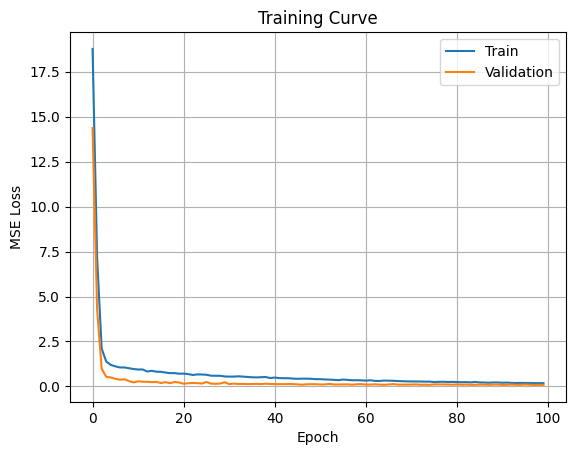

In [119]:
import matplotlib.pyplot as plt
plt.figure()

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title("Training Curve")

plt.legend()
plt.grid()

plt.show()


In [120]:
model.eval()

predictions = []
targets = []

with torch.no_grad():

    for grid,target in val_loader:

        pred = model(grid)

        predictions.extend(pred.numpy())
        targets.extend(target.numpy())

predictions = np.array(predictions).flatten()
targets = np.array(targets).flatten()


In [75]:
print(X_np.shape)
plt.plot(y_np)
plt.show()

for i in range(17):
    plt.plot(X_np[:,i])
    plt.show()

NameError: name 'X_np' is not defined

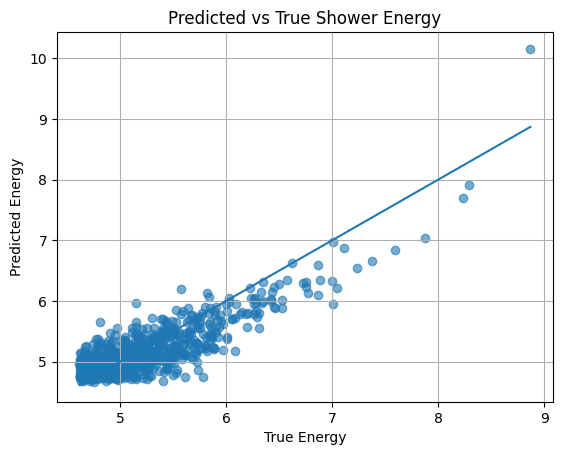

In [121]:
plt.figure()

plt.scatter(targets,predictions,alpha=0.6)

plt.xlabel("True Energy")
plt.ylabel("Predicted Energy")

plt.title("Predicted vs True Shower Energy")

plt.plot(
    [targets.min(),targets.max()],
    [targets.min(),targets.max()]
)

plt.grid()

plt.show()


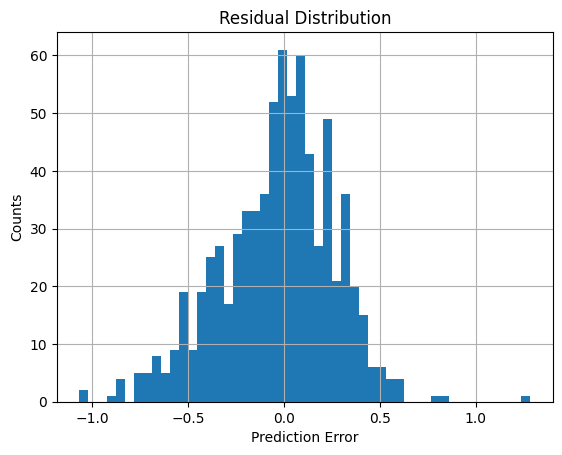

In [122]:
residuals = predictions - targets

plt.figure()

plt.hist(residuals,bins=50)

plt.xlabel("Prediction Error")
plt.ylabel("Counts")

plt.title("Residual Distribution")

plt.grid()

plt.show()


### **Predicción en test**